# Ví dụ 15

In [16]:
# !pip install numpy matplotlib scikit-fuzzy scipy

# Bước 1 Xác định không gian nền và tập mờ của D, G, T

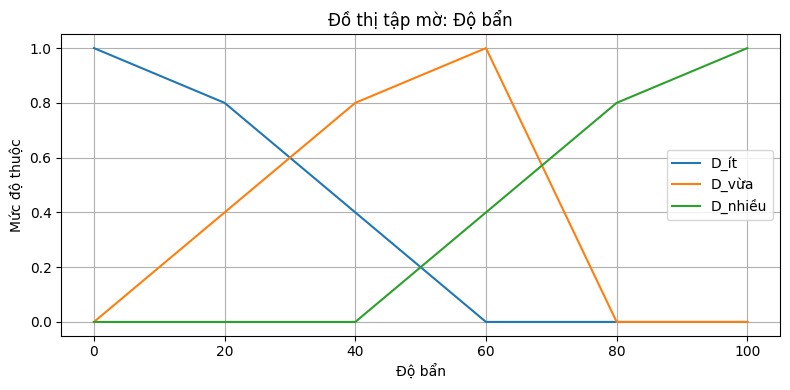

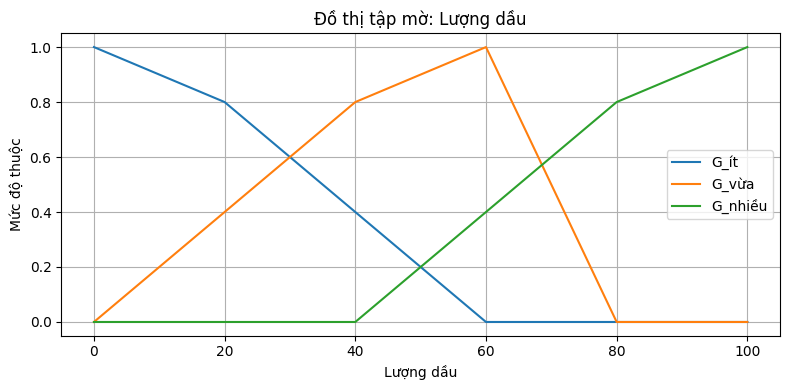

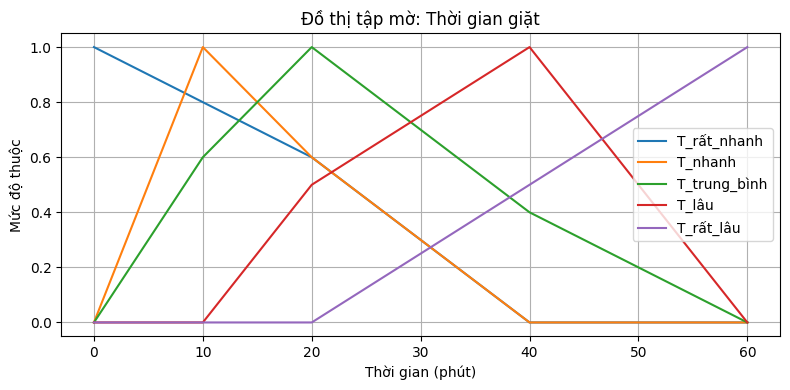

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz

# ==========================================
# 1. Xác định không gian nền
# ==========================================
x_D = np.array([0, 20, 40, 60, 80, 100])  # Độ bẩn
x_G = np.array([0, 20, 40, 60, 80, 100])  # Lượng dầu
x_T = np.array([0, 10, 20, 40, 60])       # Thời gian giặt

# ==========================================
# Xây dựng tập mờ (Hàm thuộc)
# ==========================================
D_ít = np.array([1.0, 0.8, 0.4, 0.0, 0.0, 0.0])
D_vừa = np.array([0.0, 0.4, 0.8, 1.0, 0.0, 0.0])
D_nhiều = np.array([0.0, 0.0, 0.0, 0.4, 0.8, 1.0])

G_ít = np.array([1.0, 0.8, 0.4, 0.0, 0.0, 0.0])
G_vừa = np.array([0.0, 0.4, 0.8, 1.0, 0.0, 0.0])
G_nhiều = np.array([0.0, 0.0, 0.0, 0.4, 0.8, 1.0])

T_rất_nhanh = np.array([1.0, 0.8, 0.6, 0.0, 0.0])
T_nhanh = np.array([0.0, 1.0, 0.6, 0.0, 0.0])
T_trung_bình = np.array([0.0, 0.6, 1.0, 0.4, 0.0])
T_lâu = np.array([0.0, 0.0, 0.5, 1.0, 0.0])
T_rất_lâu = np.array([0.0, 0.0, 0.0, 0.5, 1.0])

# ==========================================
# Vẽ đồ thị hàm thuộc (CHỈ vẽ tập mờ gốc)
# ==========================================
plt.figure(figsize=(8, 4))
for name, mf in [("D_ít", D_ít), ("D_vừa", D_vừa), ("D_nhiều", D_nhiều)]:
    plt.plot(x_D, mf, label=name)
plt.title("Đồ thị tập mờ: Độ bẩn")
plt.xlabel("Độ bẩn"); plt.ylabel("Mức độ thuộc")
plt.grid(True); plt.legend()
plt.tight_layout(); plt.show()

plt.figure(figsize=(8, 4))
for name, mf in [("G_ít", G_ít), ("G_vừa", G_vừa), ("G_nhiều", G_nhiều)]:
    plt.plot(x_G, mf, label=name)
plt.title("Đồ thị tập mờ: Lượng dầu")
plt.xlabel("Lượng dầu"); plt.ylabel("Mức độ thuộc")
plt.grid(True); plt.legend()
plt.tight_layout(); plt.show()

plt.figure(figsize=(8, 4))
for name, mf in [("T_rất_nhanh", T_rất_nhanh), ("T_nhanh", T_nhanh), 
                 ("T_trung_bình", T_trung_bình), ("T_lâu", T_lâu), ("T_rất_lâu", T_rất_lâu)]:
    plt.plot(x_T, mf, label=name)
plt.title("Đồ thị tập mờ: Thời gian giặt")
plt.xlabel("Thời gian (phút)"); plt.ylabel("Mức độ thuộc")
plt.grid(True); plt.legend()
plt.tight_layout(); plt.show()


![Hệ thống mờ](/workspaces/sgu26_fuzzy_logic_app/Bai03/image.png)

# Bước 2: Xác định các hàm thuộc

In [18]:

# =====================================================
# HÀM THUỘC CHO ĐỘ BẨN D
# =====================================================

# μD_ít(x)
def mu_D_it(x):

    if 0 <= x <= 20:
        return 1 + (-0.2) * x / 20

    elif 20 < x <= 40:
        return 0.8 + (-0.4) * (x - 20) / 20

    elif 40 < x <= 60:
        return 0.4 + (-0.4) * (x - 40) / 20

    elif 60 < x <= 100:
        return 0

    return 0


# μD_vừa(x)
def mu_D_vua(x):

    if 0 <= x <= 20:
        return 0.4 * x / 20

    elif 20 < x <= 40:
        return 0.4 + 0.4 * (x - 20) / 20

    elif 40 < x <= 60:
        return 0.8 + 0.2 * (x - 40) / 20

    elif 60 < x <= 80:
        return 1 + (-1) * (x - 60) / 20

    elif 80 < x <= 100:
        return 0

    return 0


# μD_nhiều(x)
def mu_D_nhieu(x):

    if 0 <= x <= 40:
        return 0

    elif 40 < x <= 60:
        return 0.4 * (x - 40) / 20

    elif 60 < x <= 80:
        return 0.4 + 0.4 * (x - 60) / 20

    elif 80 < x <= 100:
        return 0.8 + 0.2 * (x - 80) / 20

    return 0


# =====================================================
# HÀM THUỘC CHO LƯỢNG DẦU G
# =====================================================

# μG_ít(x)
def mu_G_it(x):

    if 0 <= x <= 20:
        return 1 + (-0.2) * x / 20

    elif 20 < x <= 40:
        return 0.8 + (-0.4) * (x - 20) / 20

    elif 40 < x <= 60:
        return 0.4 + (-0.4) * (x - 40) / 20

    elif 60 < x <= 100:
        return 0

    return 0


# μG_vừa(x)
def mu_G_vua(x):

    if 0 <= x <= 20:
        return 0.4 * x / 20

    elif 20 < x <= 40:
        return 0.4 + 0.4 * (x - 20) / 20

    elif 40 < x <= 60:
        return 0.8 + 0.2 * (x - 40) / 20

    elif 60 < x <= 80:
        return 1 + (-1) * (x - 60) / 20

    elif 80 < x <= 100:
        return 0

    return 0


# μG_nhiều(x)
def mu_G_nhieu(x):

    if 0 <= x <= 40:
        return 0

    elif 40 < x <= 60:
        return 0.4 * (x - 40) / 20

    elif 60 < x <= 80:
        return 0.4 + 0.4 * (x - 60) / 20

    elif 80 < x <= 100:
        return 0.8 + 0.2 * (x - 80) / 20

    return 0


# =====================================================
# HÀM THUỘC CHO THỜI GIAN GIẶT T
# =====================================================

# μT_rất_nhanh(x)
def mu_T_rat_nhanh(x):

    if 0 <= x <= 10:
        return 1 + (-0.2) * x / 10

    elif 10 < x <= 20:
        return 0.8 + (-0.2) * (x - 10) / 10

    elif 20 < x <= 40:
        return 0.6 + (-0.6) * (x - 20) / 20

    elif 40 < x <= 60:
        return 0

    return 0


# μT_nhanh(x)
def mu_T_nhanh(x):

    if 0 <= x <= 10:
        return x / 10

    elif 10 < x <= 20:
        return 1 + (-0.4) * (x - 10) / 10

    elif 20 < x <= 40:
        return 0.6 + (-0.6) * (x - 20) / 20

    elif 40 < x <= 60:
        return 0

    return 0


# μT_trung_bình(x)
def mu_T_trung_binh(x):

    if 0 <= x <= 10:
        return 0.6 * x / 10

    elif 10 < x <= 20:
        return 0.6 + 0.4 * (x - 10) / 10

    elif 20 < x <= 40:
        return 1 + (-0.6) * (x - 20) / 20

    elif 40 < x <= 60:
        return 0.4 + (-0.4) * (x - 40) / 20

    return 0


# μT_lâu(x)
def mu_T_lau(x):

    if 0 <= x <= 10:
        return 0

    elif 10 < x <= 20:
        return 0.5 * (x - 10) / 10

    elif 20 < x <= 40:
        return 0.5 + 0.5 * (x - 20) / 20

    elif 40 < x <= 60:
        return 1 + (-1) * (x - 40) / 20

    return 0


# μT_rất_lâu(x)
def mu_T_rat_lau(x):

    if 0 <= x <= 20:
        return 0

    elif 20 < x <= 40:
        return 0.5 * (x - 20) / 20

    elif 40 < x <= 60:
        return 0.5 + 0.5 * (x - 40) / 20

    return 0

# Bước 3: Xây dựng luật mờ

## Bảng luật mờ
|            | D_ít            | D_vừa           | D_nhiều         |
|------------|-----------------|-----------------|-----------------|
| **G_ít**   | T_rất_nhanh     | T_nhanh         | T_trung_bình    |
| **G_vừa**  | T_trung_bình    | T_trung_bình    | T_lâu           |
| **G_nhiều**| T_lâu           | T_lâu           | T_rất_lâu       |

## Các luật mờ
(R1): IF độ bẩn là ít và lượng dầu là ít THEN thời gian giặt là rất nhanh

(R2): IF độ bẩn là vừa và lượng dầu là ít THEN thời gian giặt là nhanh

(R3): IF độ bẩn là nhiều và lượng dầu là ít THEN thời gian giặt là trung bình

(R4): IF độ bẩn là ít và lượng dầu là vừa THEN thời gian giặt là trung bình

(R5): IF độ bẩn là vừa và lượng dầu là vừa THEN thời gian giặt là trung bình

(R6): IF độ bẩn là nhiều và lượng dầu là vừa THEN thời gian giặt là lâu

(R7): IF độ bẩn là ít và lượng dầu là nhiều THEN thời gian giặt là lâu

(R8): IF độ bẩn là vừa và lượng dầu là nhiều THEN thời gian giặt là lâu

(R9): IF độ bẩn là nhiều và lượng dầu là nhiều THEN thời gian giặt là rất lâu



# Bước 4: Suy diễn mờ với dữ liệu cụ thể

In [19]:
x0 = 40   # độ bẩn
y0 = 60   # lượng dầu

mu_D_it_value     = mu_D_it(x0)
mu_D_vua_value    = mu_D_vua(x0)
mu_D_nhieu_value  = mu_D_nhieu(x0)

mu_G_it_value     = mu_G_it(y0)
mu_G_vua_value    = mu_G_vua(y0)
mu_G_nhieu_value  = mu_G_nhieu(y0)

print("mu_D_it     =", mu_D_it_value)
print("mu_D_vua    =", mu_D_vua_value)
print("mu_D_nhieu  =", mu_D_nhieu_value)

print("mu_G_it     =", mu_G_it_value)
print("mu_G_vua    =", mu_G_vua_value)
print("mu_G_nhieu  =", mu_G_nhieu_value)

mu_D_it     = 0.4
mu_D_vua    = 0.8
mu_D_nhieu  = 0
mu_G_it     = 0.0
mu_G_vua    = 1.0
mu_G_nhieu  = 0.4


In [20]:
# ==========================================
# Trọng số các luật mờ
# ==========================================

# w1 = D_nhiều AND G_nhiều
w1 = min(mu_D_nhieu(x0), mu_G_nhieu(y0))

# w2 = D_nhiều AND G_vừa
w2 = min(mu_D_nhieu(x0), mu_G_vua(y0))

# w3 = D_nhiều AND G_ít
w3 = min(mu_D_nhieu(x0), mu_G_it(y0))

# w4 = D_vừa AND G_nhiều
w4 = min(mu_D_vua(x0), mu_G_nhieu(y0))

# w5 = D_vừa AND G_vừa
w5 = min(mu_D_vua(x0), mu_G_vua(y0))

# w6 = D_vừa AND G_ít
w6 = min(mu_D_vua(x0), mu_G_it(y0))

# w7 = D_ít AND G_nhiều
w7 = min(mu_D_it(x0), mu_G_nhieu(y0))

# w8 = D_ít AND G_vừa
w8 = min(mu_D_it(x0), mu_G_vua(y0))

# w9 = D_ít AND G_ít
w9 = min(mu_D_it(x0), mu_G_it(y0))


# ==========================================
# In trọng số
# ==========================================

print("========== HỆ SỐ KÍCH HOẠT ==========")

print(f"w1 = {w1:.2f}")
print(f"w2 = {w2:.2f}")
print(f"w3 = {w3:.2f}")
print(f"w4 = {w4:.2f}")
print(f"w5 = {w5:.2f}")
print(f"w6 = {w6:.2f}")
print(f"w7 = {w7:.2f}")
print(f"w8 = {w8:.2f}")
print(f"w9 = {w9:.2f}")

print("===================================")

========== HỆ SỐ KÍCH HOẠT ==========
w1 = 0.00
w2 = 0.00
w3 = 0.00
w4 = 0.40
w5 = 0.80
w6 = 0.00
w7 = 0.40
w8 = 0.40
w9 = 0.00


# Bước 5: Ghép luật, giải mờ

In [ ]:
# ==========================================
# KHÔNG GIAN NỀN ĐẦU RA
# ==========================================

# thì:
# z là trục thời gian giặt
# μT(z) là độ thuộc tại mỗi thời gian.

z = np.linspace(0, 60, 200) # chia thành các điểm rất nhỏ, z chính là biến tích phân trong công thức centroid.
# chia đoạn [0,60]
# thành rất nhiều điểm nhỏ
# rồi xấp xỉ tích phân số.



# ==========================================
# TẬP MỜ ĐẦU RA SAU KHI NHÂN TRỌNG SỐ
# ==========================================

# nghĩa là: tại MỖI giá trị thời gian zi 	​
# tính độ thuộc của tập thời gian giặt

R1 = w1 * np.array([mu_T_rat_lau(i) for i in z])

R2 = w2 * np.array([mu_T_lau(i) for i in z])

R3 = w3 * np.array([mu_T_trung_binh(i) for i in z])

R4 = w4 * np.array([mu_T_lau(i) for i in z])

R5 = w5 * np.array([mu_T_trung_binh(i) for i in z])

R6 = w6 * np.array([mu_T_nhanh(i) for i in z])

R7 = w7 * np.array([mu_T_lau(i) for i in z])

R8 = w8 * np.array([mu_T_trung_binh(i) for i in z])

R9 = w9 * np.array([mu_T_rat_nhanh(i) for i in z])

# ==========================================
# GHÉP LUẬT BẰNG PHÉP CỘNG
# ==========================================

mu_T = (
    R1 + R2 + R3 +
    R4 + R5 + R6 +
    R7 + R8 + R9
)

# ==========================================
# CHUẨN HÓA
# ==========================================

if np.max(mu_T) != 0:
    mu_T = mu_T / np.max(mu_T)

# ==========================================
# GIẢI MỜ Mamdani
# ==========================================

# Xấp xỉ tổng Riemann / quy tắc hình thang rời rạc

z_centroid = fuzz.defuzz(z, mu_T, 'centroid')

print("========== GIẢI MỜ ==========")
print(f"Thời gian giặt = {z_centroid:.2f} phút")
print("================================")

========== GIẢI MỜ ==========
Thời gian giặt = 29.15 phút


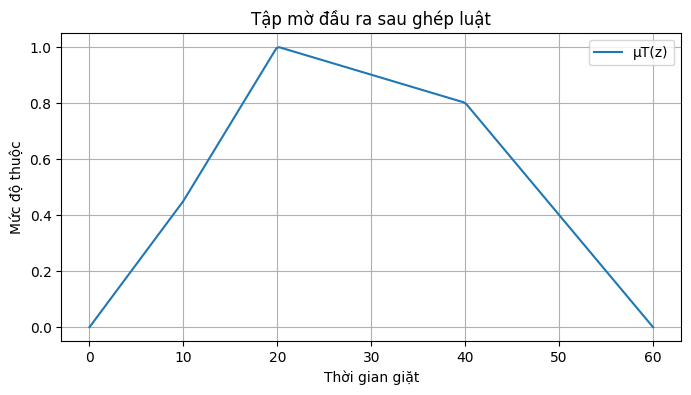

In [22]:
plt.figure(figsize=(8,4))

plt.plot(z, mu_T, label='μT(z)')

plt.xlabel("Thời gian giặt")
plt.ylabel("Mức độ thuộc")

plt.title("Tập mờ đầu ra sau ghép luật")

plt.grid(True)
plt.legend()

plt.show()